In [40]:
import pandas as pd
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
folder_path = './client'  

csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

df_client = pd.concat((pd.read_csv(file, delimiter=", ", engine="python") for file in csv_files), ignore_index=True)

In [42]:
folder_path = './server'  

csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

df_server = pd.concat((pd.read_csv(file, delimiter=", ", engine="python") for file in csv_files), ignore_index=True)

In [43]:
df = pd.merge(
    df_client,
    df_server,
    on=["Transport Protocol", "Scenario", "Distance (m)"],
    how="inner"  # Only rows that exist in both will be kept
)

In [44]:
df["Distance (m)"] = df["Distance (m)"].replace(30,5)
df = df[df["Transfer Speed (Mbps)"] < 5000]

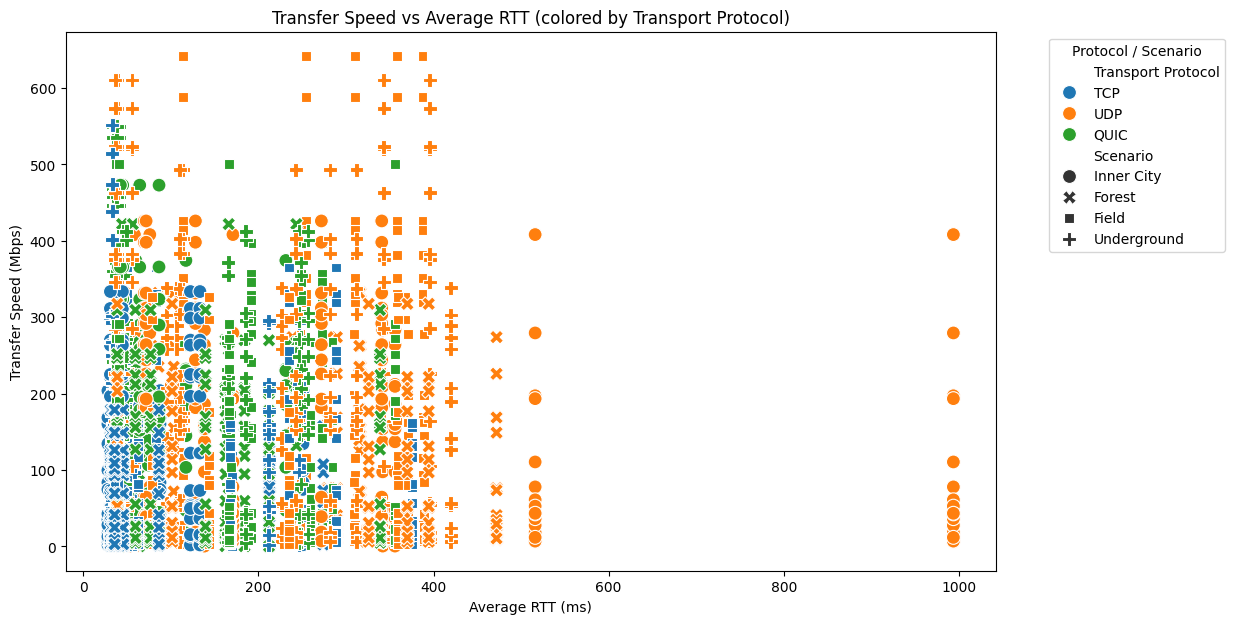

In [45]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Average RTT (ms)', 
    y='Transfer Speed (Mbps)', 
    hue='Transport Protocol', 
    style='Scenario',
    data=df,
    s=100
)
plt.title('Transfer Speed vs Average RTT (colored by Transport Protocol)')
plt.xlabel('Average RTT (ms)')
plt.ylabel('Transfer Speed (Mbps)')
plt.legend(title='Protocol / Scenario', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

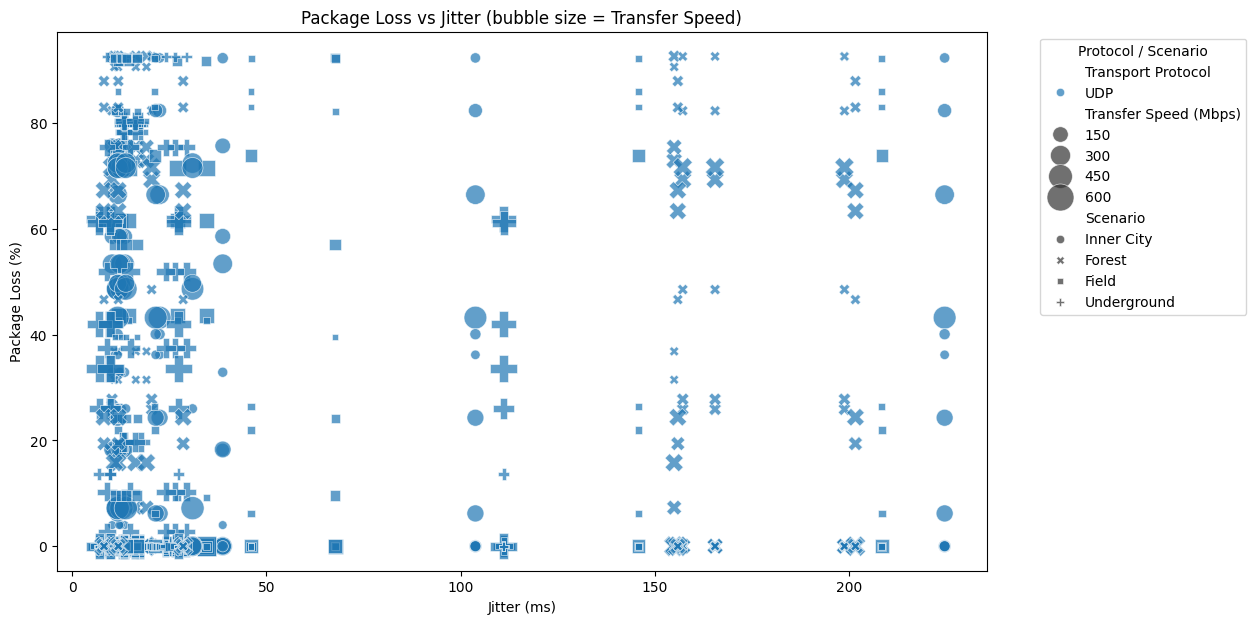

In [46]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Jitter (ms)', 
    y='Package Loss (%)', 
    size='Transfer Speed (Mbps)', 
    hue='Transport Protocol',
    style='Scenario',
    data=df[df["Transport Protocol"] == "UDP"],
    sizes=(40, 400),
    alpha=0.7
)
plt.title('Package Loss vs Jitter (bubble size = Transfer Speed)')
plt.xlabel('Jitter (ms)')
plt.ylabel('Package Loss (%)')
plt.legend(title='Protocol / Scenario', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

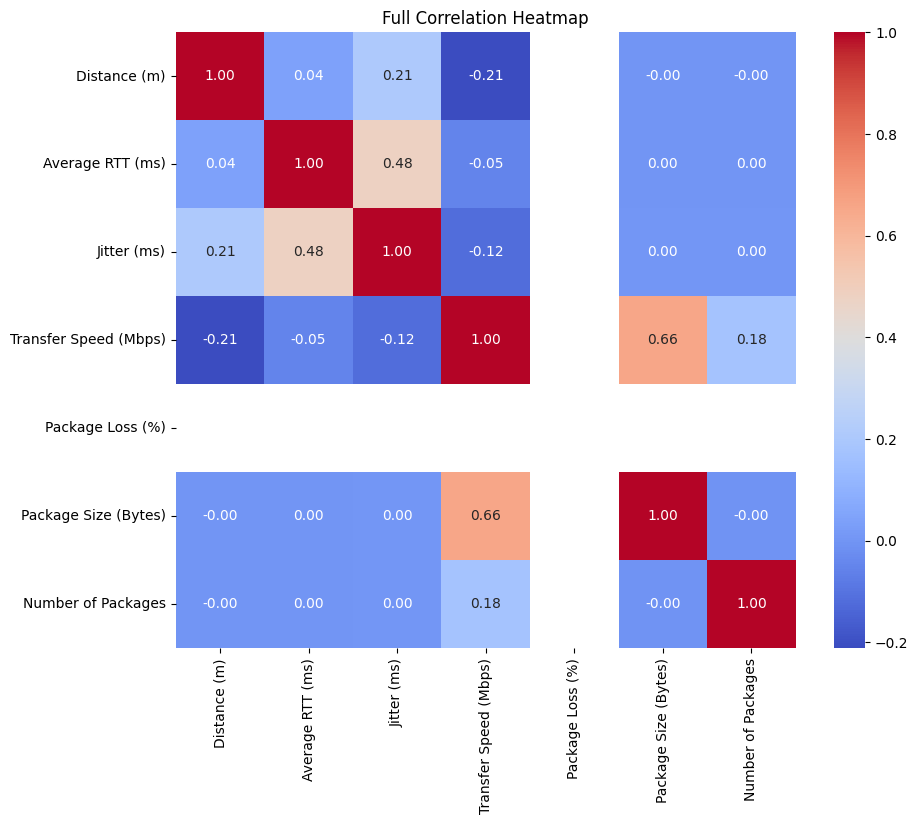

In [47]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[df["Transport Protocol"] == "QUIC"].corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Full Correlation Heatmap')
plt.show()

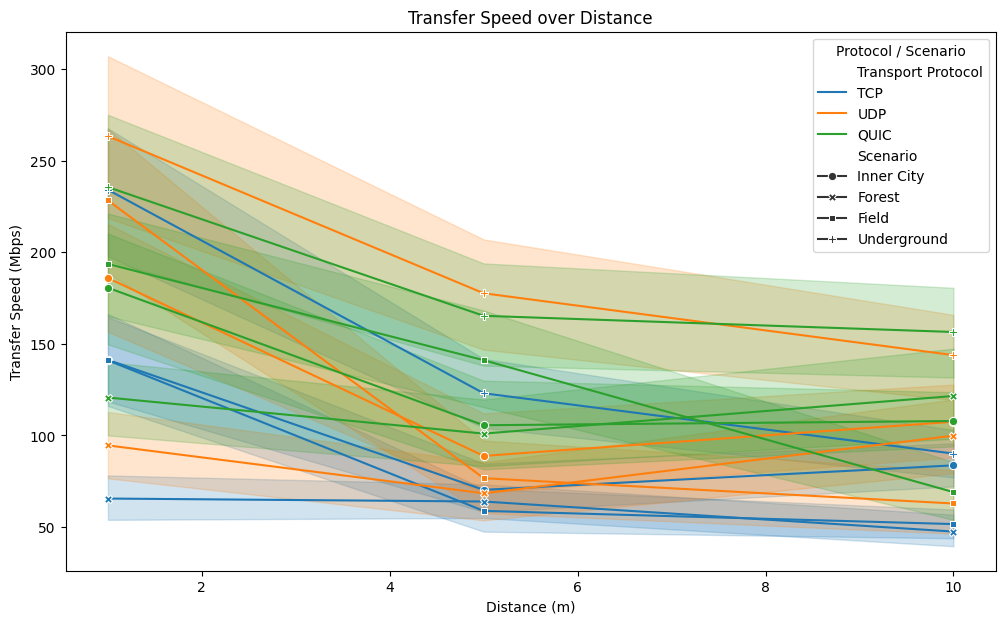

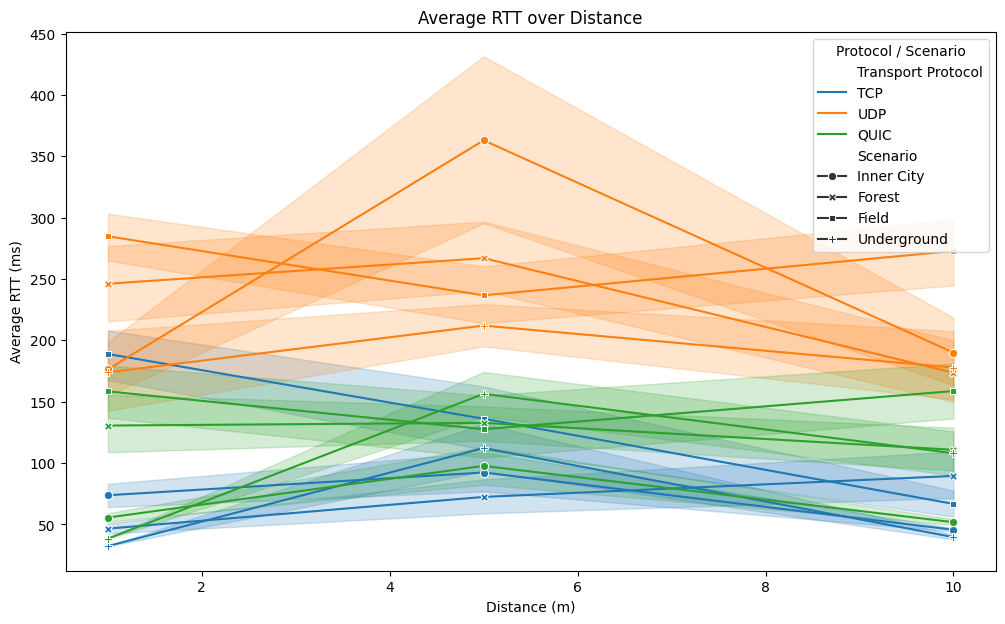

In [48]:
plt.figure(figsize=(12, 7))

# Plot Transfer Speed
sns.lineplot(
    x='Distance (m)', 
    y='Transfer Speed (Mbps)', 
    hue='Transport Protocol', 
    style='Scenario',
    markers=True,
    dashes=False,
    data=df,
    legend='full'
)
plt.title('Transfer Speed over Distance')
plt.xlabel('Distance (m)')
plt.ylabel('Transfer Speed (Mbps)')
plt.legend(title='Protocol / Scenario')
plt.show()

# Plot RTT separately
plt.figure(figsize=(12, 7))
sns.lineplot(
    x='Distance (m)', 
    y='Average RTT (ms)', 
    hue='Transport Protocol', 
    style='Scenario',
    markers=True,
    dashes=False,
    data=df,
    legend='full'
)
plt.title('Average RTT over Distance')
plt.xlabel('Distance (m)')
plt.ylabel('Average RTT (ms)')
plt.legend(title='Protocol / Scenario')
plt.show()